In [6]:
# Download Kaggle Dataset
!pip install -q kagglehub pandas ultralytics seaborn
import kagglehub
import os

print("Downloading dataset...")
path = kagglehub.dataset_download("sirakr/houses-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'houses-dataset' dataset.
Path to dataset files: /kaggle/input/houses-dataset


/tmp/ipykernel_2709/1116366484.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['${:,.0f}'.format(x) for x in current_values])


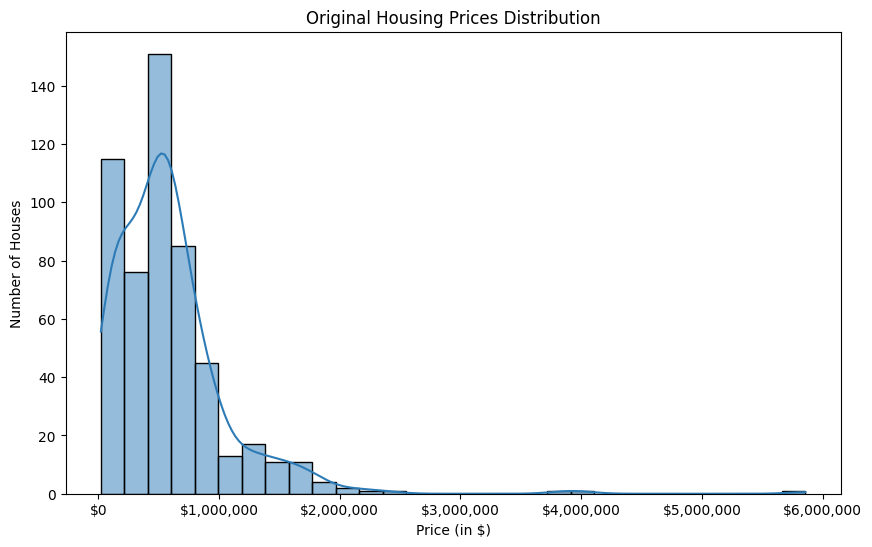

In [7]:
# Visualize Original Distribution
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically locate the text file
txt_path = glob.glob(f"{path}/**/HousesInfo.txt", recursive=True)[0]
base_dir = os.path.dirname(txt_path)

cols = ["Bedrooms", "Bathrooms", "Area", "Zipcode", "Price"]
df = pd.read_csv(txt_path, sep=" ", names=cols)
df['House_ID'] = df.index + 1

# Plot original skewed data
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='#2c7bb6')
plt.title('Original Housing Prices Distribution')
plt.xlabel('Price (in $)')
plt.ylabel('Number of Houses')

# Format x-axis to show dollars
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['${:,.0f}'.format(x) for x in current_values])
plt.show()

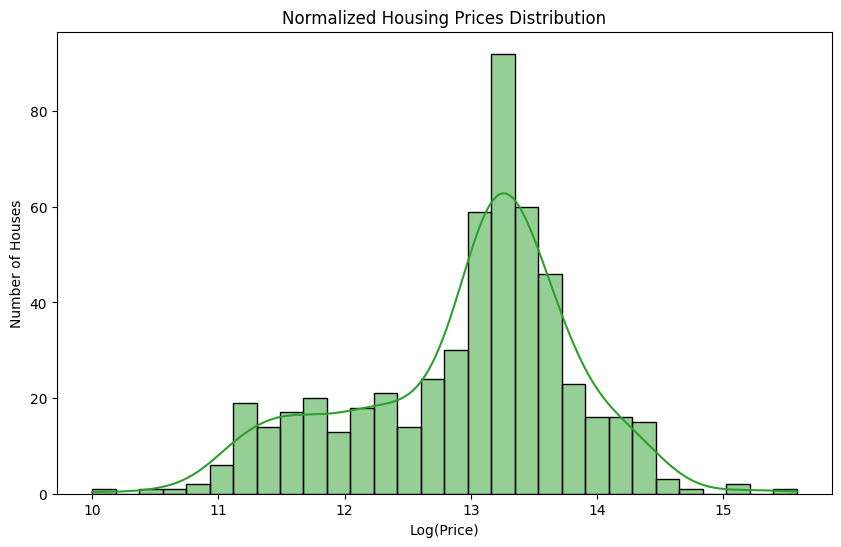

In [8]:
# Fix Price Distribution
import numpy as np

# Apply Log Transformation to fix the skew
df['Log_Price'] = np.log1p(df['Price'])

# Plot the normalized data
plt.figure(figsize=(10, 6))
sns.histplot(df['Log_Price'], bins=30, kde=True, color='#2ca02c')
plt.title('Normalized Housing Prices Distribution')
plt.xlabel('Log(Price)')
plt.ylabel('Number of Houses')
plt.show()

In [9]:
# Process Location Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# One-Hot Encode Zipcodes
df = pd.get_dummies(df, columns=['Zipcode'], drop_first=True)

# Separate features from target
tabular_cols = [c for c in df.columns if c not in ['Price', 'House_ID', 'Log_Price']]
X_tab = df[tabular_cols].values.astype(np.float32)
y_log = df['Log_Price'].values

# Scale data
tab_scaler = StandardScaler()
X_tab_scaled = tab_scaler.fit_transform(X_tab)

price_scaler = MinMaxScaler()
y_scaled = price_scaler.fit_transform(y_log.reshape(-1, 1))

num_tab_features = X_tab_scaled.shape[1]

# PyTorch Dataset Class
class RealEstateDataset(Dataset):
    def __init__(self, tabular_data, prices, house_ids, image_dir, transform=None):
        self.tabular_data = tabular_data
        self.prices = prices
        self.house_ids = house_ids
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.tabular_data)

    def __getitem__(self, idx):
        tab = torch.tensor(self.tabular_data[idx], dtype=torch.float32)
        price = torch.tensor(self.prices[idx], dtype=torch.float32)

        house_id = self.house_ids[idx]
        img_path = os.path.join(self.image_dir, f"{house_id}_frontal.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new('RGB', (128, 128), color='black')

        if self.transform:
            image = self.transform(image)

        return tab, image, price

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Splits and Loaders
train_idx, test_idx = train_test_split(range(len(df)), test_size=0.2, random_state=42)

train_dataset = RealEstateDataset(X_tab_scaled[train_idx], y_scaled[train_idx], df['House_ID'].values[train_idx], base_dir, transform)
test_dataset = RealEstateDataset(X_tab_scaled[test_idx], y_scaled[test_idx], df['House_ID'].values[test_idx], base_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print("✅ DataLoaders configured with Zipcode features!")

✅ DataLoaders configured with Zipcode features!


In [26]:
# Dynamic Multimodal Architecture
import torch.nn as nn
from ultralytics import YOLO

class DynamicYoloPredictor(nn.Module):
    def __init__(self, num_tabular):
        super(DynamicYoloPredictor, self).__init__()

        # YOLOv8 Vision Brain
        print("Downloading YOLOv8 weights...")
        yolo = YOLO('yolov8n-cls.pt')
        self.vision_extractor = yolo.model
        for param in self.vision_extractor.parameters():
            param.requires_grad = False
        self.vision_extractor.model[-1].linear = nn.Identity()

        self.cnn_compress = nn.Sequential(
            nn.Linear(1280, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Tabular Brain
        self.mlp = nn.Sequential(
            nn.Linear(num_tabular, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion Brain
        self.fusion = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, tab_data, img_data):
        img_features = self.vision_extractor(img_data)
        if isinstance(img_features, (tuple, list)):
            img_features = img_features[-1]

        img_features = self.cnn_compress(img_features)
        tab_features = self.mlp(tab_data)

        combined = torch.cat((img_features, tab_features), dim=1)
        return self.fusion(combined)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DynamicYoloPredictor(num_tab_features).to(device)
print(f"✅ Architecture Built and moved to {device.type.upper()}!")

✅ Architecture Built and moved to CUDA!


In [28]:
# Train High Accuracy Model
import torch.optim as optim
import copy

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 200
patience = 10 # UPDATED: Aggressive early stopping set to 10 epochs
best_val_loss = float('inf')
patience_counter = 0

# FIXED AND VERIFIED: Loss tracking lists are initialized here!
train_losses = []
val_losses = []

print(f"🚀 Starting Final Training with Patience 10...")

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0
    for tab_data, img_data, target_price in train_loader:
        tab_data, img_data, target_price = tab_data.to(device), img_data.to(device), target_price.to(device)
        optimizer.zero_grad()
        loss = criterion(model(tab_data, img_data), target_price)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * tab_data.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss) # Tracking Training Loss

    model.eval()
    running_val_loss = 0.0
    accurate_predictions = 0

    with torch.no_grad():
        for tab_data, img_data, target_price in test_loader:
            tab_data, img_data, target_price = tab_data.to(device), img_data.to(device), target_price.to(device)
            predictions = model(tab_data, img_data)

            running_val_loss += criterion(predictions, target_price).item() * tab_data.size(0)

            margin_of_error = 0.15
            accurate_predictions += torch.sum(torch.abs(predictions - target_price) < margin_of_error).item()

    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss) # Tracking Validation Loss

    custom_accuracy = (accurate_predictions / len(test_loader.dataset)) * 100
    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        status = "🟢 Improved!"
    else:
        patience_counter += 1
        status = f"🔴 Waiting ({patience_counter}/{patience})"

    if (epoch + 1) % 5 == 0 or patience_counter >= patience:
        print(f"Epoch {epoch+1:03d}/{num_epochs} | Val Loss: {epoch_val_loss:.4f} | Accuracy: {custom_accuracy:.1f}% | {status}")

    if patience_counter >= patience:
        print(f"\n🛑 EARLY STOPPING TRIGGERED! Model stopped after 10 epochs without improvement.")
        break

model.load_state_dict(best_model_weights)
print("✅ Best weights restored! Training Complete.")

🚀 Starting Final Training with Patience 10...
Epoch 005/200 | Val Loss: 0.0406 | Accuracy: 44.9% | 🔴 Waiting (1/10)
Epoch 010/200 | Val Loss: 0.0425 | Accuracy: 37.4% | 🔴 Waiting (4/10)
Epoch 015/200 | Val Loss: 0.0218 | Accuracy: 61.7% | 🟢 Improved!
Epoch 020/200 | Val Loss: 0.0167 | Accuracy: 72.0% | 🟢 Improved!
Epoch 025/200 | Val Loss: 0.0165 | Accuracy: 72.9% | 🟢 Improved!
Epoch 030/200 | Val Loss: 0.0160 | Accuracy: 76.6% | 🔴 Waiting (1/10)
Epoch 035/200 | Val Loss: 0.0122 | Accuracy: 87.9% | 🔴 Waiting (3/10)
Epoch 040/200 | Val Loss: 0.0207 | Accuracy: 67.3% | 🔴 Waiting (3/10)
Epoch 045/200 | Val Loss: 0.0098 | Accuracy: 89.7% | 🔴 Waiting (8/10)
Epoch 047/200 | Val Loss: 0.0099 | Accuracy: 91.6% | 🔴 Waiting (10/10)

🛑 EARLY STOPPING TRIGGERED! Model stopped after 10 epochs without improvement.
✅ Best weights restored! Training Complete.


In [36]:
# Export Trained Model
import torch

model_save_path = "yolov8_final_multimodal_housing.pth"
torch.save(model.state_dict(), model_save_path)

print(f"✅ Best model weights successfully saved as '{model_save_path}'")

✅ Best model weights successfully saved as 'yolov8_final_multimodal_housing.pth'


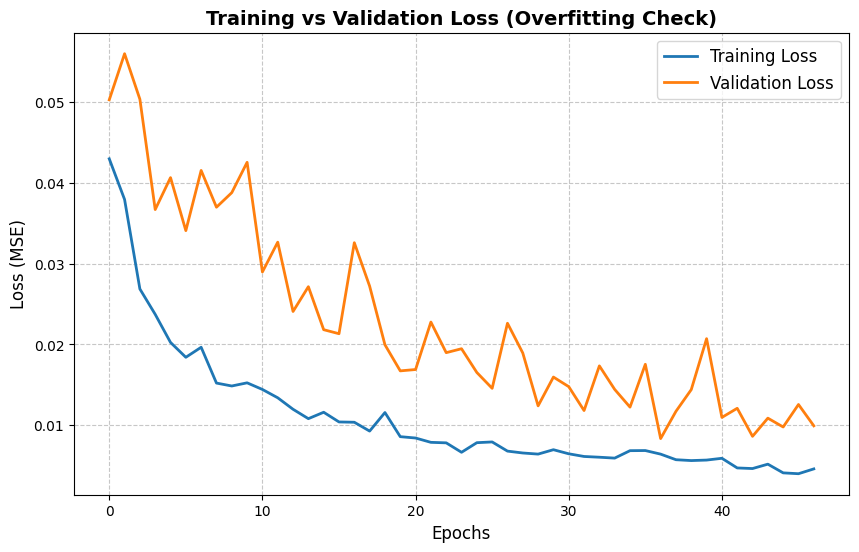

In [30]:
# Plot Loss Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2)

plt.title('Training vs Validation Loss (Overfitting Check)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [31]:
# Evaluate Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for tab_data, img_data, target_price in test_loader:
        tab_data, img_data = tab_data.to(device), img_data.to(device)
        preds = model(tab_data, img_data).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(target_price.cpu().numpy())

# Reverse scaling
preds_unscaled = price_scaler.inverse_transform(all_preds)
targets_unscaled = price_scaler.inverse_transform(np.array(all_targets).reshape(-1, 1))

# Reverse Log Transformation
final_preds_dollars = np.expm1(preds_unscaled)
final_targets_dollars = np.expm1(targets_unscaled)

# Calculate final required metrics
mae = mean_absolute_error(final_targets_dollars, final_preds_dollars)
rmse = np.sqrt(mean_squared_error(final_targets_dollars, final_preds_dollars))

print("\n📈 Final Official Evaluation Metrics:")
print("-" * 40)
print(f"Mean Absolute Error (MAE):         ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):    ${rmse:,.2f}")
print("-" * 40)


📈 Final Official Evaluation Metrics:
----------------------------------------
Mean Absolute Error (MAE):         $205,185.56
Root Mean Squared Error (RMSE):    $321,342.59
----------------------------------------
